In [4]:
import pandas as pd

modelo = "OZABAG"
modelo = "ECS"
modelos = ['ECS', 'ECS1', 'ECSEspecialized', 'AWE', 'BLAST', 'BOLE', 'DACC', 'DWM', 'OZABAG',
           'OZABAG_ADWIN', 'RCD', 'PLkNN', 'ADOB', 'OzaBoost', 'LeveragingBag', 'IBLeveragingBag', 'ECSBestSingle',
             'ECSBest', 'ECSBest_w_4', 'ECSBest_w_4_e_0.3', 'ECSOld', 'ECSBestSinglePrior', 'ECSBestSingle2']
fh = 30
df_results = pd.DataFrame()
for fh in [120, 150, 180, 210, 240]:
    for modelo in modelos:
        df = pd.read_csv(f'resultados/resultados_{modelo}.csv')    
        df_filtered = df[df['modelo'] == modelo]
        df_filtered = df_filtered[df_filtered['fh'] == fh]
        df_linha = pd.DataFrame()
        df_linha[modelo] = modelo
        df_linha["profit"] = df_filtered["profit"].mean()
        df_results = pd.concat([df_results, pd.DataFrame({'modelo' : modelo, 'profit' : df_filtered['profit'].mean(), 'fh' : fh}, index=[0])], ignore_index=True)


df_profits = pd.DataFrame()
for modelo in modelos:
    df_modelo = df_results[df_results['modelo'] == modelo]
    profit_medio = df_modelo['profit'].mean()
    df_profits = pd.concat([df_profits, pd.DataFrame({'modelo': modelo, 'profit_medio': profit_medio}, index=[0])], ignore_index=True)

df_profits = df_profits.sort_values(by='profit_medio', ascending=False)
print(df_profits)



                modelo  profit_medio
19   ECSBest_w_4_e_0.3      2.289274
18         ECSBest_w_4      2.284533
17             ECSBest      2.284533
11               PLkNN      2.200200
1                 ECS1      2.178596
21  ECSBestSinglePrior      2.177953
10                 RCD      2.125065
14       LeveragingBag      2.119711
9         OZABAG_ADWIN      2.109508
4                BLAST      2.056781
12                ADOB      2.055213
3                  AWE      2.039968
6                 DACC      2.039844
0                  ECS      1.946222
13            OzaBoost      1.882616
7                  DWM      1.853431
8               OZABAG      1.787813
5                 BOLE      1.745069
15     IBLeveragingBag      1.314305
2      ECSEspecialized      1.306232
22      ECSBestSingle2      1.051040
16       ECSBestSingle      1.034126
20              ECSOld      1.000000


In [24]:
df_res = df_results[df_results['fh'] == 30]
# df_res = df_results[df_results['modelo'] == 'ECSEspecialized']

df_res.sort_values(by='profit', ascending=False)


,modelo,profit,fh
25,AWE,2.088604,30
24,ECSEspecialized,1.843049,30
36,LeveragingBag,1.513957,30
28,DACC,1.451698,30
31,OZABAG_ADWIN,1.445156,30
35,OzaBoost,1.390902,30
38,ECSBest,1.339055,30
40,ECSBest_w_4_e_0.3,1.339055,30
39,ECSBest_w_4,1.339055,30
22,ECS,1.331501,30


In [ ]:
BLAST	1.544822	- 1

IBDWM	1.278945- 30
IBLeveragingBag	1.696280 - 60
IBDWM	1.563531 - 60
OZABAG_ADWIN	1.575054	 - 90
PLkNN	1.628121 - 120
ECSEspecialized	1.301445 - 150
BOLE	1.485941 - 180
IBLeveragingBag	1.347927 - 210
OZABAG_ADWIN	1.331746 - 210
BOLE	1.502952 - 240

In [ ]:
import pandas as pd

modelos = ['ECS', 'AWE', 'BLAST', 'BOLE', 'DACC', 'DWM', 'OZABAG', 
                  'OZABAG_ADWIN', 'PLkNN', 'ADOB', 'OzaBoost', 'LeveragingBag', 'ECSBest',
                  'IBDWM', 'IBLeveragingBag', 'ECSEspecialized',  'ECSLimited']
df_results = pd.DataFrame()
forecast_horizon = 150
for modelo in modelos:
    df_modelo = pd.DataFrame()
    for fh in [1, 30, 60, 90, 120, 150, 180, 210, 240]:

        if modelo == 'ECSBestSingle' or modelo == 'ECSBestSingle2' or modelo == 'ECSLimited' or modelo == 'ECS':
            df = pd.read_csv(f'resultados/resultados_{modelo}.csv')
        else:
            df = pd.read_csv(f'resultados_de/resultados_{modelo}.csv')
        df = df[df['fh'] == fh]
        df_linha = pd.DataFrame()
        df_linha['modelo'] = [modelo]
        df_linha['fh'] = [fh]
        df_linha['profit_mean'] = [df.Accuracy.mean()]
        df_linha['profit_std'] = [df.Accuracy.std()]
        df_linha['profit_max'] = [df.Accuracy.max()]
        df_linha['profit_min'] = [df.Accuracy.min()]
        df_modelo = pd.concat([df_modelo, df_linha], ignore_index=True)
    
    # df_results['modelo'] = [modelo]
    df_results_row = pd.DataFrame()
    df_results_row['modelo'] = [modelo]
    df_results_row['profit_mean'] = df_modelo['profit_mean'].mean()
    df_results_row['profit_std'] = df_modelo['profit_std'].mean()
    df_results_row['profit_max'] = df_modelo['profit_max'].mean()
    df_results_row['profit_min'] = df_modelo['profit_min'].mean()
    df_results = pd.concat([df_results, df_results_row], ignore_index=True)

# df_results['modelo'] = [modelo]
buyAndHoldDf = df[df['modelo'] == 'ECSLimited']

df_results_row = pd.DataFrame()
df_results_row['modelo'] = ['buyAndHold']
df_results_row['profit_mean'] = buyAndHoldDf['buyAndHoldProfit'].mean()
df_results_row['profit_std'] = buyAndHoldDf['buyAndHoldProfit'].std()
df_results_row['profit_max'] = buyAndHoldDf['buyAndHoldProfit'].max()
df_results_row['profit_min'] = buyAndHoldDf['buyAndHoldProfit'].min()
df_results = pd.concat([df_results, df_results_row], ignore_index=True)

df_results.sort_values(by='profit_mean', ascending=False).reset_index(drop=True)

,modelo,profit_mean,profit_std,profit_max,profit_min
0,buyAndHold,1.500902,1.128926,6.221176,0.110820
1,ECSLimited,1.346278,1.239875,8.965716,0.264801
2,IBLeveragingBag,1.340638,1.251092,9.480761,0.182213
3,OZABAG_ADWIN,1.338788,1.338740,10.260887,0.193301
4,ADOB,1.317562,1.182885,8.773214,0.214362
5,OzaBoost,1.288806,0.986165,6.850145,0.230219
6,BOLE,1.282282,1.020255,7.254788,0.191066
7,LeveragingBag,1.278430,1.008422,7.079931,0.220251
8,BLAST,1.277363,1.339393,9.921818,0.166364
9,OZABAG,1.273033,1.082393,8.478667,0.267140


Gráfico de desempenho por horizonte

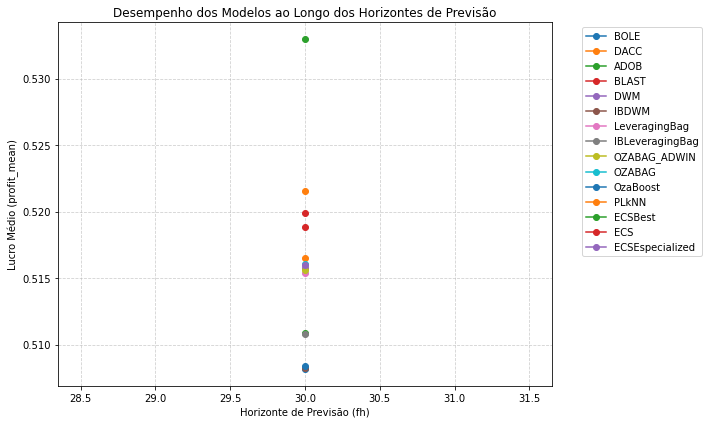

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Lista de modelos
modelos = [
    'BOLE', 'DACC', 'ADOB',  'BLAST', 'DWM',
    'IBDWM', 'LeveragingBag', 'IBLeveragingBag',
    'OZABAG_ADWIN', 'OZABAG', 'OzaBoost', 'PLkNN', 'ECSBest', 'ECS', 'ECSEspecialized'
]

# Lista de horizontes de previsão
horizontes = [30]

# DataFrame final com todos os resultados por modelo e horizonte
df_all = pd.DataFrame()

# Loop pelos modelos e horizontes
for modelo in modelos:
    for fh in horizontes:
        # Escolhe o caminho do arquivo
        if modelo in ['ECSBestSingle', 'ECSBestSingle2']:
            df = pd.read_csv(f'resultados/resultados_{modelo}.csv')
        else:
            df = pd.read_csv(f'resultados_de/resultados_{modelo}.csv')

        # Filtra pelo horizonte atual
        df = df[df['fh'] == fh]

        # Adiciona estatísticas ao dataframe geral
        df_all = pd.concat([
            df_all,
            pd.DataFrame({
                'modelo': [modelo],
                'fh': [fh],
                'profit_mean': [df['Accuracy'].mean()],
                'profit_std': [df['Accuracy'].std()],
                'profit_max': [df['Accuracy'].max()],
                'profit_min': [df['Accuracy'].min()]
            })
        ], ignore_index=True)

# --- GRÁFICO ---
plt.figure(figsize=(10, 6))

# Uma linha por modelo
for modelo in modelos:
    df_modelo = df_all[df_all['modelo'] == modelo]
    plt.plot(df_modelo['fh'], df_modelo['profit_mean'], marker='o', label=modelo)

plt.title('Desempenho dos Modelos ao Longo dos Horizontes de Previsão')
plt.xlabel('Horizonte de Previsão (fh)')
plt.ylabel('Lucro Médio (profit_mean)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Teste estatístico

TESTE DE FRIEDMAN

Estatística de Friedman: 39.4379
P-valor: 0.000312
Conclusão: Há diferença significativa entre os modelos

TESTE POST-HOC DE NEMENYI

Ranking médio dos modelos (menor é melhor):
----------------------------------------
ECSBest             : 6.924
AWE                 : 7.384
IBLeveragingBag     : 7.665
IBDWM               : 7.755
PLkNN               : 7.820
ECS                 : 7.927
BLAST               : 8.041
DWM                 : 8.076
OZABAG              : 8.096
LeveragingBag       : 8.194
OZABAG_ADWIN        : 8.194
ADOB                : 8.241
DACC                : 8.300
OzaBoost            : 8.425
BOLE                : 8.957


Diferença Crítica (CD) para α=0.05: 1.3106

Comparações par-a-par:
ECSBest              vs ADOB                : Diferença = 1.3176 - SIGNIFICATIVA
ECSBest              vs DACC                : Diferença = 1.3765 - SIGNIFICATIVA
ECSBest              vs OzaBoost            : Diferença = 1.5020 - SIGNIFICATIVA
ECSBest              vs BOLE  

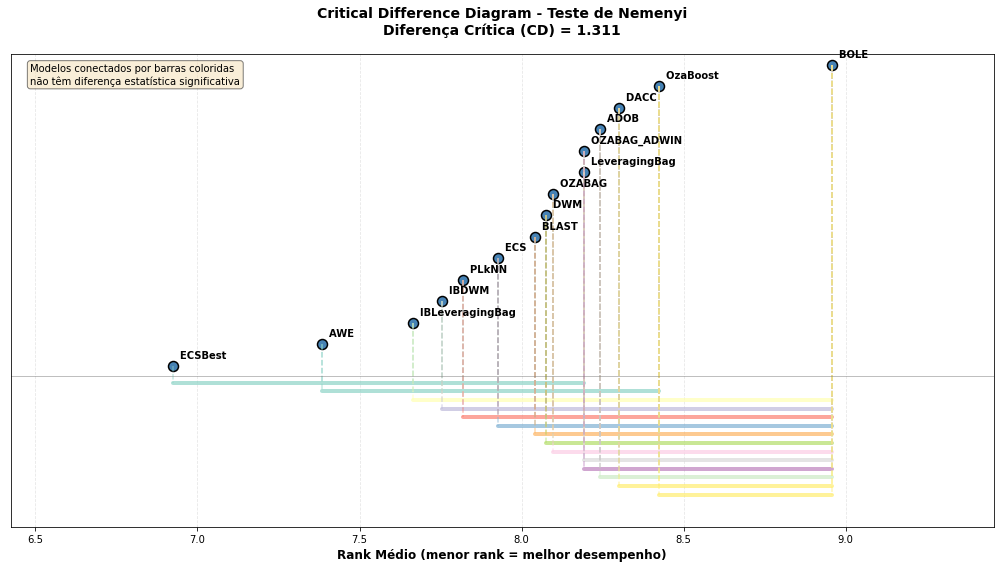

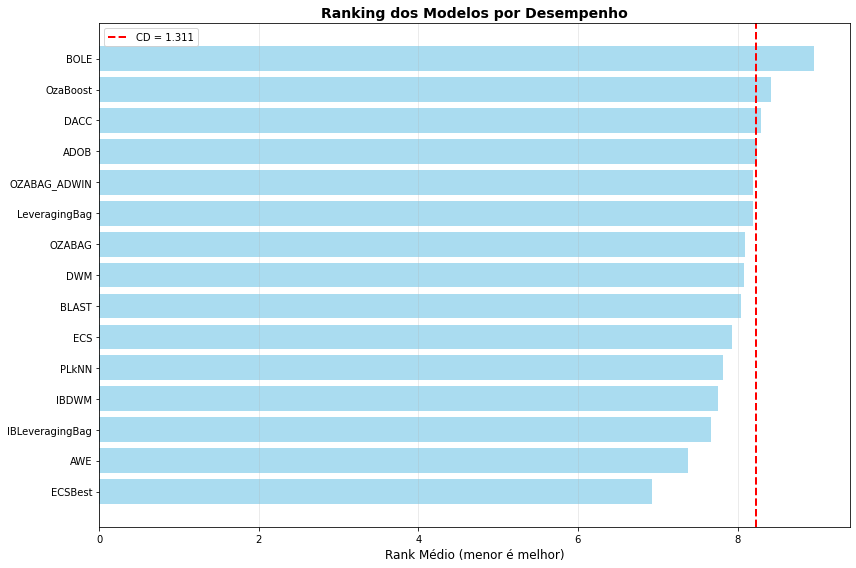

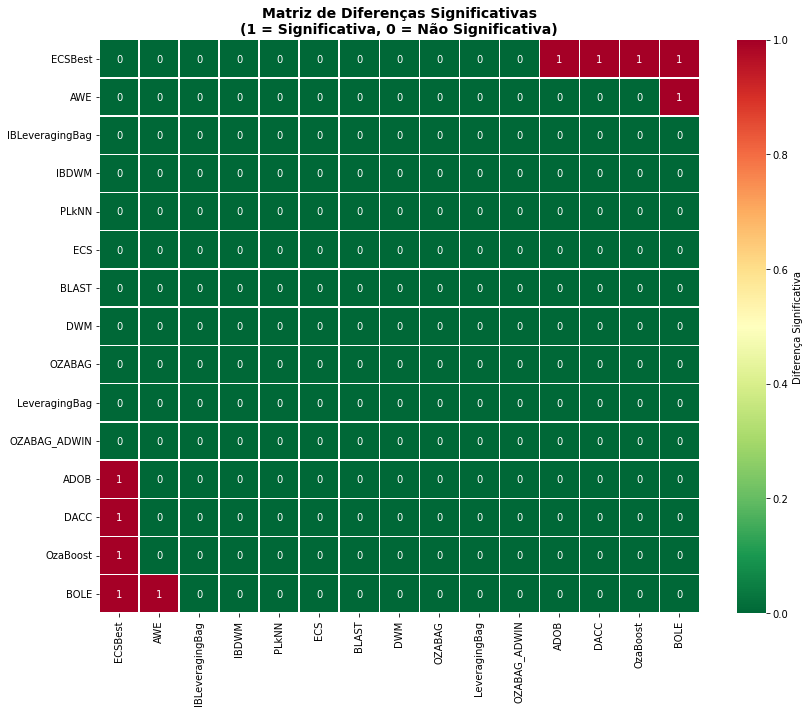

In [60]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Seus modelos
modelos = ['BOLE', 'DACC', 'ADOB', 'AWE', 'BLAST', 'DWM', 'IBDWM', 'LeveragingBag', 'IBLeveragingBag',
           'OZABAG_ADWIN', 'OZABAG', 'OzaBoost', 'PLkNN', 'ECSBest', 'ECS']

# Coletar dados de profit para cada modelo
data_for_test = []
forecast_horizon = 150

for modelo in modelos:
    profits = []
    for fh in [1, 30, 60, 90]:
        if modelo == 'ECSBestSingle' or modelo == 'ECSBestSingle2':
            df = pd.read_csv(f'resultados/resultados_{modelo}.csv')
        else:
            df = pd.read_csv(f'resultados_de/resultados_{modelo}.csv')
        df = df[df['fh'] == fh]
        profits.extend(df.Accuracy.values)
    data_for_test.append(profits)

# Criar DataFrame com todos os profits (linhas = observações, colunas = modelos)
max_len = max(len(x) for x in data_for_test)
df_profits = pd.DataFrame({modelos[i]: data_for_test[i] + [np.nan]*(max_len - len(data_for_test[i])) 
                           for i in range(len(modelos))})

# Remover linhas com NaN
df_profits_clean = df_profits.dropna()

print("="*80)
print("TESTE DE FRIEDMAN")
print("="*80)

# Teste de Friedman
statistic, p_value = stats.friedmanchisquare(*[df_profits_clean[col].values for col in df_profits_clean.columns])
print(f"\nEstatística de Friedman: {statistic:.4f}")
print(f"P-valor: {p_value:.6f}")
print(f"Conclusão: {'Há diferença significativa entre os modelos' if p_value < 0.05 else 'Não há diferença significativa'}")

print("\n" + "="*80)
print("TESTE POST-HOC DE NEMENYI")
print("="*80)

# Calcular ranks para cada observação
ranks = df_profits_clean.rank(axis=1, ascending=False)
mean_ranks = ranks.mean(axis=0).sort_values()

print("\nRanking médio dos modelos (menor é melhor):")
print("-" * 40)
for modelo, rank in mean_ranks.items():
    print(f"{modelo:20s}: {rank:.3f}")

# Teste de Nemenyi
n_models = len(modelos)
n_obs = len(df_profits_clean)

# Diferença crítica (Critical Difference)
# q_alpha é o valor crítico da distribuição studentized range para alpha=0.05
q_alpha = 3.309  # Para 13 modelos e alpha=0.05 (aproximado)
cd = q_alpha * np.sqrt((n_models * (n_models + 1)) / (6 * n_obs))

print(f"\n\nDiferença Crítica (CD) para α=0.05: {cd:.4f}")
print("\nComparações par-a-par:")
print("="*80)

# Matriz de diferenças significativas
diff_matrix = pd.DataFrame(index=mean_ranks.index, columns=mean_ranks.index)
sig_matrix = pd.DataFrame(index=mean_ranks.index, columns=mean_ranks.index)

for i, model1 in enumerate(mean_ranks.index):
    for j, model2 in enumerate(mean_ranks.index):
        diff = abs(mean_ranks[model1] - mean_ranks[model2])
        diff_matrix.loc[model1, model2] = diff
        sig_matrix.loc[model1, model2] = diff > cd
        
        if i < j and diff > cd:
            print(f"{model1:20s} vs {model2:20s}: Diferença = {diff:.4f} - SIGNIFICATIVA")

# Visualização: Critical Difference Diagram Tradicional
fig, ax = plt.subplots(figsize=(14, 8))

# Ordenar modelos por rank
sorted_models = mean_ranks.sort_values().index.tolist()
sorted_ranks = mean_ranks.sort_values().values

# Configurar posições verticais
y_positions = np.arange(len(sorted_models))
line_height = 0.3

# Desenhar linhas horizontais para cada modelo
for i, (modelo, rank) in enumerate(zip(sorted_models, sorted_ranks)):
    ax.plot([rank, rank], [i - line_height/2, i + line_height/2], 
            'k-', linewidth=2)
    ax.plot(rank, i, 'o', markersize=10, color='steelblue', 
            markeredgecolor='black', markeredgewidth=1.5)

# Adicionar nomes dos modelos
for i, modelo in enumerate(sorted_models):
    ax.text(sorted_ranks[i], i + 0.5, f'  {modelo}', 
            va='center', ha='left', fontsize=10, fontweight='bold')

# Desenhar conexões (cliques) entre modelos não significativamente diferentes
connected_groups = []
for i in range(len(sorted_models)):
    grupo = [i]
    for j in range(i + 1, len(sorted_models)):
        if abs(sorted_ranks[i] - sorted_ranks[j]) <= cd:
            grupo.append(j)
        else:
            break
    if len(grupo) > 1:
        connected_groups.append(grupo)

# Desenhar barras horizontais conectando grupos não significativos
colors = plt.cm.Set3(np.linspace(0, 1, len(connected_groups)))
offset_y = -0.8
for idx, grupo in enumerate(connected_groups):
    if len(grupo) > 1:
        min_idx = min(grupo)
        max_idx = max(grupo)
        min_rank = sorted_ranks[min_idx]
        max_rank = sorted_ranks[max_idx]
        
        # Desenhar linha horizontal conectando o grupo
        y_line = offset_y
        ax.plot([min_rank, max_rank], [y_line, y_line], 
                linewidth=4, color=colors[idx], alpha=0.7, solid_capstyle='round')
        
        # Desenhar linhas verticais conectando aos pontos
        for i in grupo:
            ax.plot([sorted_ranks[i], sorted_ranks[i]], [i, y_line], 
                    linewidth=1.5, color=colors[idx], alpha=0.5, linestyle='--')
        
        offset_y -= 0.4

# Configurar eixos
ax.set_ylim(-len(connected_groups) * 0.5 - 0.5, len(sorted_models) - 0.5)
ax.set_xlim(sorted_ranks[0] - 0.5, sorted_ranks[-1] + 0.5)
ax.set_xlabel('Rank Médio (menor rank = melhor desempenho)', fontsize=12, fontweight='bold')
ax.set_title('Critical Difference Diagram - Teste de Nemenyi\n' + 
             f'Diferença Crítica (CD) = {cd:.3f}', 
             fontsize=14, fontweight='bold', pad=20)

# Remover ticks do eixo y
ax.set_yticks([])

# Adicionar grid vertical
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.axhline(y=-0.5, color='gray', linestyle='-', linewidth=0.5)

# Adicionar legenda
legend_text = 'Modelos conectados por barras coloridas\nnão têm diferença estatística significativa'
ax.text(0.02, 0.98, legend_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('critical_difference_diagram.png', dpi=300, bbox_inches='tight')
print("\n\nCritical Difference Diagram salvo como 'critical_difference_diagram.png'")

# Visualização adicional: Barras horizontais simples
plt.figure(figsize=(12, 8))

y_positions = np.arange(len(sorted_models))

# Plot dos ranks
plt.barh(y_positions, sorted_ranks, color='skyblue', alpha=0.7)
plt.yticks(y_positions, sorted_models)
plt.xlabel('Rank Médio (menor é melhor)', fontsize=12)
plt.title('Ranking dos Modelos por Desempenho', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Adicionar linha de diferença crítica
best_rank = sorted_ranks[0]
plt.axvline(best_rank + cd, color='red', linestyle='--', linewidth=2, label=f'CD = {cd:.3f}')
plt.legend()

plt.tight_layout()
plt.savefig('nemenyi_bars.png', dpi=300, bbox_inches='tight')
print("Gráfico de barras salvo como 'nemenyi_bars.png'")

# Heatmap de diferenças significativas
plt.figure(figsize=(12, 10))
sig_matrix_numeric = sig_matrix.astype(int)
sns.heatmap(sig_matrix_numeric, annot=True, cmap='RdYlGn_r', cbar_kws={'label': 'Diferença Significativa'},
            fmt='d', linewidths=0.5)
plt.title('Matriz de Diferenças Significativas\n(1 = Significativa, 0 = Não Significativa)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nemenyi_heatmap.png', dpi=300, bbox_inches='tight')
print("Heatmap salvo como 'nemenyi_heatmap.png'")

print("\n" + "="*80)
print("RESUMO ESTATÍSTICO")
print("="*80)
df_summary = pd.DataFrame({
    'Modelo': mean_ranks.index,
    'Rank_Medio': mean_ranks.values,
    'Profit_Mean': [df_profits_clean[col].mean() for col in mean_ranks.index],
    'Profit_Std': [df_profits_clean[col].std() for col in mean_ranks.index]
})
df_summary = df_summary.sort_values('Rank_Medio')
print("\n", df_summary.to_string(index=False))

# Análise de conclusões e ranking
print("\n" + "="*80)
print("CONCLUSÕES E RANKING FINAL")
print("="*80)

# Identificar o melhor modelo
best_model = mean_ranks.idxmin()
best_rank = mean_ranks.min()

print(f"\n🏆 MELHOR MODELO: {best_model}")
print(f"   Rank Médio: {best_rank:.3f}")
print(f"   Profit Médio: {df_profits_clean[best_model].mean():.4f}")

# Para cada modelo, identificar quais ele supera significativamente
print("\n" + "="*80)
print("ANÁLISE DETALHADA POR MODELO (ordenado do melhor para o pior)")
print("="*80)

for rank_position, modelo in enumerate(mean_ranks.index, 1):
    modelo_rank = mean_ranks[modelo]
    profit_mean = df_profits_clean[modelo].mean()
    
    # Modelos que este supera significativamente
    supera = []
    # Modelos que superam este significativamente
    superado_por = []
    # Modelos estatisticamente equivalentes
    equivalentes = []
    
    for outro_modelo in mean_ranks.index:
        if modelo == outro_modelo:
            continue
        
        diff = abs(mean_ranks[modelo] - mean_ranks[outro_modelo])
        
        if diff > cd:
            # Há diferença significativa
            if mean_ranks[modelo] < mean_ranks[outro_modelo]:
                # Este modelo é melhor (rank menor)
                supera.append(outro_modelo)
            else:
                # Este modelo é pior
                superado_por.append(outro_modelo)
        else:
            # Estatisticamente equivalentes
            equivalentes.append(outro_modelo)
    
    print(f"\n{rank_position}. {modelo}")
    print(f"   {'─'*70}")
    print(f"   Rank Médio: {modelo_rank:.3f}")
    print(f"   Profit Médio: {profit_mean:.4f} (±{df_profits_clean[modelo].std():.4f})")
    print(f"   Profit Máximo: {df_profits_clean[modelo].max():.4f}")
    print(f"   Profit Mínimo: {df_profits_clean[modelo].min():.4f}")
    
    if supera:
        print(f"\n   ✓ SUPERA significativamente ({len(supera)} modelos):")
        for m in supera:
            diff_rank = mean_ranks[m] - mean_ranks[modelo]
            print(f"      • {m:20s} (Δrank = {diff_rank:+.3f})")
    else:
        print(f"\n   ✓ Não supera significativamente nenhum modelo")
    
    if superado_por:
        print(f"\n   ✗ SUPERADO POR ({len(superado_por)} modelos):")
        for m in superado_por:
            diff_rank = mean_ranks[modelo] - mean_ranks[m]
            print(f"      • {m:20s} (Δrank = {diff_rank:+.3f})")
    else:
        print(f"\n   ✗ Não é superado significativamente por nenhum modelo")
    
    if equivalentes:
        print(f"\n   ≈ EQUIVALENTE a ({len(equivalentes)} modelos):")
        for m in equivalentes:
            print(f"      • {m}")

# Resumo final
print("\n" + "="*80)
print("RESUMO EXECUTIVO")
print("="*80)

top_3 = mean_ranks.head(3)
print(f"\n📊 TOP 3 MODELOS:")
for i, (modelo, rank) in enumerate(top_3.items(), 1):
    profit = df_profits_clean[modelo].mean()
    n_supera = sum(abs(mean_ranks[modelo] - mean_ranks[m]) > cd and mean_ranks[modelo] < mean_ranks[m] 
                   for m in mean_ranks.index if m != modelo)
    print(f"   {i}. {modelo:20s} - Rank: {rank:.3f}, Profit: {profit:.4f}, Supera: {n_supera} modelos")

bottom_3 = mean_ranks.tail(3)
print(f"\n📉 PIORES 3 MODELOS:")
for i, (modelo, rank) in enumerate(bottom_3.items(), 1):
    profit = df_profits_clean[modelo].mean()
    n_superado = sum(abs(mean_ranks[modelo] - mean_ranks[m]) > cd and mean_ranks[modelo] > mean_ranks[m] 
                     for m in mean_ranks.index if m != modelo)
    print(f"   {i}. {modelo:20s} - Rank: {rank:.3f}, Profit: {profit:.4f}, Superado por: {n_superado} modelos")

# Grupos estatisticamente equivalentes
print(f"\n🔍 GRUPOS DE MODELOS ESTATISTICAMENTE EQUIVALENTES:")
grupos_identificados = set()
grupo_num = 1

for i, modelo1 in enumerate(mean_ranks.index):
    if modelo1 in grupos_identificados:
        continue
    
    grupo = [modelo1]
    for modelo2 in mean_ranks.index[i+1:]:
        if modelo2 in grupos_identificados:
            continue
        if abs(mean_ranks[modelo1] - mean_ranks[modelo2]) <= cd:
            grupo.append(modelo2)
    
    if len(grupo) > 1:
        print(f"\n   Grupo {grupo_num}: {len(grupo)} modelos equivalentes")
        for m in grupo:
            print(f"      • {m:20s} (Rank: {mean_ranks[m]:.3f})")
            grupos_identificados.add(m)
        grupo_num += 1

print("\n" + "="*80)

plt.show()

In [15]:
df = pd.read_csv(f'resultados_de/resultados_AWE.csv')
df.dropna(inplace=True)
df.profit.mean()    

TypeError: Could not convert 1.01.01.00.64251456041968040.57930107526881720.87092399756155211.30114810262311380.7825160401670961.01.01.17012652834309131.01.01.01.01.35459331330448431.00.83853449189361021.01.00.68583099154359131.00.995815899581591.01.01.00.95833521279954791.02.0399587084634581.00.7463590351319051.01.01.01.05996252342286050.6842936947334380.89651293588301451.00.93322865120100041.01.01.01.00.67622528599244471.01.01.01.01.16712532875895981.01.01.01.06229290921139840.64914120276849221.01.01.01.01.10084240363990450.82664560766397771.01.01.31636257338805751.01.01.01.01.02365870708275670.93620719580454291.01.01.01.01.00753138075313791.38503416978699721.01.37767969735182861.7190082586203941.01.01.01.00.83885193036231341.01.00.99279927992799281.01.00.113840957638638450.78831075872729710.73389830508474571.01.01.01.00.79129789204114150.26203208556149740.27280446385249880.49446149277250531.01.01.01.0636574538114181.01.01858333322680421.46327683615819181.87862595419847311.01.00.4634

Se acontecer:

    Could not convert 1.01.01.00.64251456041968040... tente ver se existem cabeçalhos salvos no arquivo

    